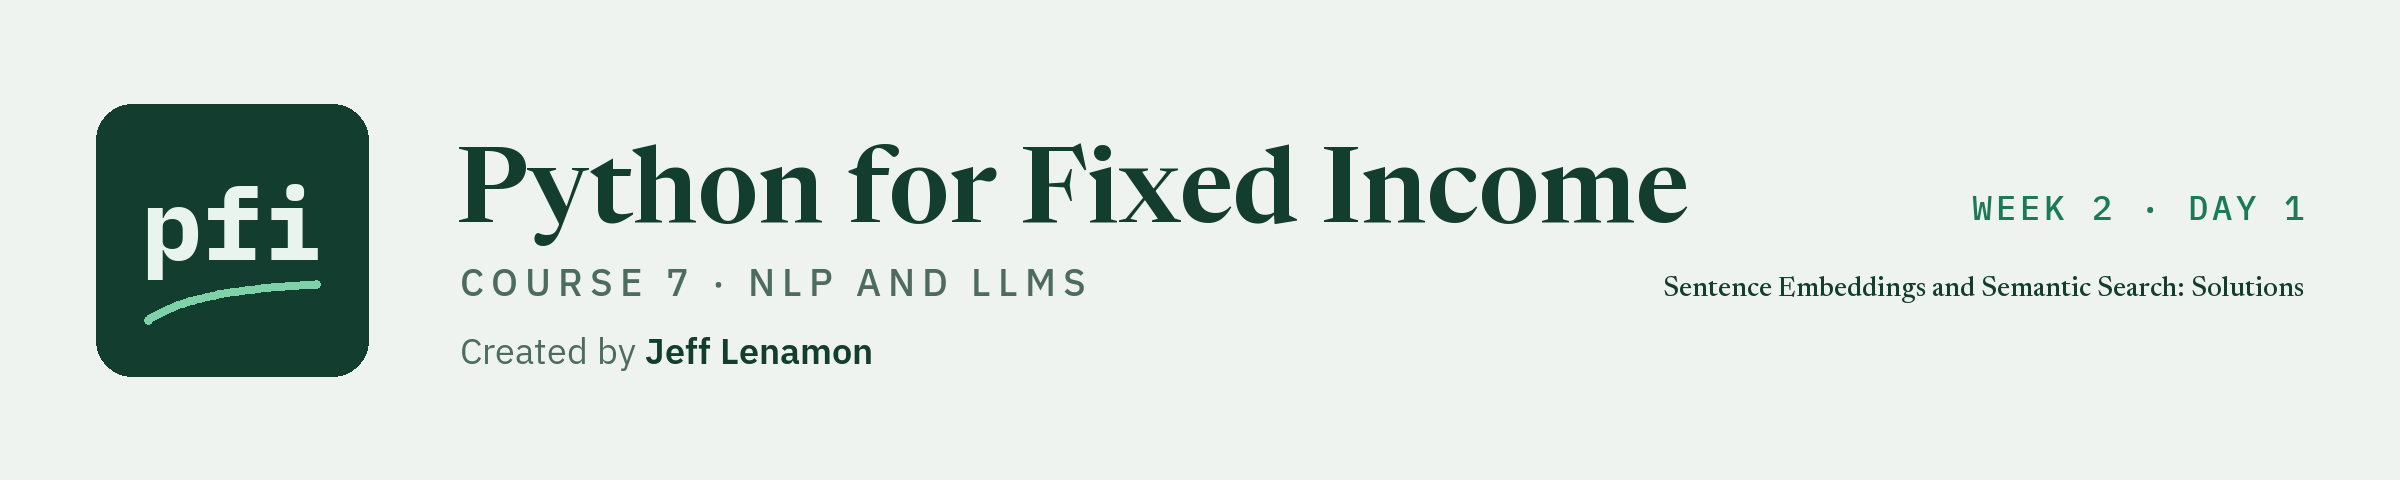

# Sentence Embeddings and Semantic Search: Solutions

Week 2, Day 1. Worked answers to the exercises. Try each one yourself first.

**Data:** `course7_indentures/boyd_2021.txt`: Boyd Gaming Corporation, Indenture dated as of June 8, 2021, 4.750% Senior Notes due 2031, Exhibit 4.1 to the 8-K filed 2021-06-08, accession 0001193125-21-185495: **real**, a public record on sec.gov, quoted for descriptive extraction only.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course7_nlp_and_llms/week2/day1/06_sentence_embeddings_and_semantic_search_solutions.ipynb)

This notebook stands on its own. Its setup writes `mlkit.py`, and `textkit.py` and `test_textkit.py` as they stand at the end of today, so the exercises can be run without the lesson; its first exercise cell loads MiniLM from your Hugging Face cache (downloading it the first time) and embeds the chunks once.

**Rows.** No model is fitted to labels or scored against labels in this notebook: every number describes the one indenture as published, a pretrained model's output on its chunks, and a TF-IDF vocabulary fitted on the same chunks to describe them.

Q. Set up today's work folder.

In [1]:
# today's setup: thread settings, quiet model loading, the modules, the seed, the course data, a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These lines must run before numpy, pandas, scikit-learn, or PyTorch is imported: if you ran another cell first,
# restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

# the model libraries print download bars and notices; these lines must run before they are imported
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

import importlib
import importlib.metadata
import importlib.util
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("torch", "torch"), ("transformers", "transformers"), ("sentence_transformers", "sentence-transformers"), ("openai", "openai"), ("pydantic", "pydantic"), ("bs4", "beautifulsoup4"), ("pypdf", "pypdf"), ("pypdfium2", "pypdfium2"), ("dotenv", "python-dotenv"), ("pytest", "pytest")]:
    if importlib.util.find_spec(module_name) is None:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.")

import numpy as np
import pandas as pd
import torch

# one thread for PyTorch too, set before it runs anything
torch.set_num_threads(1)
torch.set_num_interop_threads(1)

# the versions the saved outputs of this notebook came from (course7_nlp_and_llms/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "torch": "2.14.1", "transformers": "5.19.0", "sentence-transformers": "6.1.0", "openai": "3.26.0", "pydantic": "2.13.5", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name].split("+")[0] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42
# PyTorch's own generator; a pretrained model in evaluation mode draws no random number, but the seed costs nothing
torch.manual_seed(SEED)

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "course7_fomc_statements.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course7_06_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["course7_indentures/boyd_2021.txt"]
for name in DATA_FILES:
    (work / name).parent.mkdir(parents=True, exist_ok=True)
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, torch 2.14.1, transformers 5.19.0, sentence-transformers 6.1.0, openai 3.26.0, pydantic 2.13.5, pytest 9.1.1
Work folder: pfi_course7_06_xaku55b7, in your temp folder
Data files from the data folder of the course repo: course7_indentures/boyd_2021.txt
SEED = 42


Q. Write the earlier courses' modules today needs, unchanged: `mlkit.py`.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')


import re  # whole-word search

from sklearn.metrics import average_precision_score, roc_auc_score

# words that turn a description into a forecast, advice, or a lending decision; a reminder, not a proof
FORECAST_WORDS = ["will", "expect", "expects", "should", "forecast", "forecasts", "cheap", "rich", "attractive",
                  "signal", "signals", "buy", "sell", "approve", "decline", "lend", "invest"]


def compare_models(models: dict, X: pd.DataFrame, y: ArrayLike, thresholds: dict[str, float]) -> pd.DataFrame:
    """One row of metrics per fitted model, on the rows given.

    Inputs: models, {name: a fitted classifier with predict_proba}, fitted by the caller on training rows;
    X and y, the rows to report on (validation rows, or the test rows once at the end); thresholds,
    {name: threshold} for every model, chosen on rows other than these test rows.
    Output: a DataFrame indexed by model name with columns roc_auc and average_precision (from probabilities,
    no threshold), then threshold, accuracy, precision, recall, f1 for rows flagged at probability >= threshold.
    Convention: nothing is fitted here; an unfitted model raises scikit-learn's NotFittedError.
    Raises ValueError if models is empty or a model has no threshold.
    """
    # check every model has a threshold before computing anything
    if not models:
        raise ValueError("models is empty")
    missing = sorted(set(models) - set(thresholds))
    if missing:
        raise ValueError(f"no threshold for: {missing}")
    rows = {}
    for name, model in models.items():
        # the model probability of class 1 per row
        proba = model.predict_proba(X)[:, 1]
        # metrics that rank without a threshold, then metrics at the model's threshold
        row = {"roc_auc": roc_auc_score(y, proba), "average_precision": average_precision_score(y, proba),
               "threshold": thresholds[name]}
        row |= classification_metrics(y, (proba >= thresholds[name]).astype(int))
        rows[name] = row
    return pd.DataFrame.from_dict(rows, orient="index")


def assert_descriptive(text: str) -> None:
    """Stop if a written description uses a word from FORECAST_WORDS.

    Input: text, a description of what a model shows.
    Output: None if no listed word appears as a whole word, in any case.
    Convention: the list is a reminder, not a proof. A text can pass and still make a forecast in other words,
    and a listed word can be harmless in context; the check makes the writer look again.
    Raises ValueError naming every listed word found, in the order of FORECAST_WORDS.
    """
    # whole words only, ignoring case: "willing" does not match "will"
    found = [word for word in FORECAST_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses forecast, advice, or lending words: {found}")


def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,
                        gap: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    """Expanding-window splits for dated rows: train on the past, test on the rows that follow.

    Inputs: dates, the rows' dates, unique and ascending; min_train, the rows in the first training window;
    test_size, the rows in each test window; gap, rows left out between the last training row and the first
    test row (use the number of rows a target or feature spans; 0 for a same-day target).
    Output: a list of (train_positions, test_positions), integer positions into dates. Fold k trains on
    positions 0 to min_train + k x test_size - 1 and tests the next test_size positions after `gap` rows.
    The window steps forward by test_size; a last test window shorter than test_size is dropped.
    Convention: never shuffled; every training date is before every test date.
    Raises ValueError if the dates are not unique and ascending, min_train or test_size is below 1, gap is
    negative, or there are too few rows for one fold.
    """
    # check the dates and the sizes
    index = pd.DatetimeIndex(dates)
    if not (index.is_unique and index.is_monotonic_increasing):
        raise ValueError("dates must be unique and ascending")
    if min_train < 1 or test_size < 1 or gap < 0:
        raise ValueError(f"need min_train >= 1, test_size >= 1, gap >= 0; got {min_train}, {test_size}, {gap}")
    splits = []
    train_end = min_train  # one past the last training position
    # add folds while a whole test window fits after the gap
    while train_end + gap + test_size <= len(index):
        test_start = train_end + gap
        splits.append((np.arange(0, train_end), np.arange(test_start, test_start + test_size)))
        train_end += test_size
    if not splits:
        raise ValueError(f"{len(index)} rows are too few for min_train {min_train}, gap {gap}, test_size {test_size}")
    return splits


def assert_past_only(train_dates: ArrayLike, test_dates: ArrayLike, gap: int = 0,
                     calendar: ArrayLike | None = None) -> None:
    """Stop unless every training date is earlier than every test date, with a gap where one is asked for.

    Inputs: the dates of the training rows and of the test rows; gap, the rows of `calendar` that must lie
    strictly between the last training date and the first test date; calendar, every date of the dataset
    (needed when gap is above 0).
    Output: None when the split uses only the past.
    Raises AssertionError naming the last training date and the first test date when the order or the gap is
    wrong, and ValueError if either part is empty or a gap is asked for without a calendar.
    """
    train = pd.DatetimeIndex(train_dates)
    test = pd.DatetimeIndex(test_dates)
    if len(train) == 0 or len(test) == 0:
        raise ValueError("train_dates and test_dates must both hold at least one date")
    # the latest training date must come before the earliest test date
    last_train, first_test = train.max(), test.min()
    if not last_train < first_test:
        raise AssertionError(f"a training date ({last_train.date()}) is not before the first test date "
                             f"({first_test.date()})")
    if gap > 0:
        if calendar is None:
            raise ValueError("a gap is counted in rows of the calendar, so calendar is needed")
        # rows of the calendar strictly between the two dates
        days = pd.DatetimeIndex(calendar)
        between = int(((days > last_train) & (days < first_test)).sum())
        if between < gap:
            raise AssertionError(f"only {between} rows lie between {last_train.date()} and {first_test.date()}, "
                                 f"fewer than the gap of {gap}")


from collections.abc import Iterable

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def elbow_table(X: ArrayLike, k_values: Iterable[int], seed: int = 42) -> pd.DataFrame:
    """Inertia and silhouette of K-means for each number of clusters, to choose k by judgement.

    Inputs: X, the features already scaled (K-means measures distance, so units decide the clusters); k_values,
    the numbers of clusters to try, each 2 or more; seed, passed as random_state.
    Output: a DataFrame indexed by k (named k) with columns inertia (the within-cluster sum of squared distances,
    in squared scaled units; it falls as k rises) and silhouette (the mean silhouette coefficient, Euclidean,
    -1 to 1; higher means tighter, better separated clusters).
    Convention: KMeans(n_clusters=k, n_init=10, random_state=seed), n_init written out.
    Raises ValueError if k_values is empty, a k is below 2, or a k is not below the number of rows.
    """
    # check the k values before fitting
    ks = list(k_values)
    if not ks:
        raise ValueError("k_values is empty")
    n_rows = len(X)
    bad = [k for k in ks if k < 2 or k >= n_rows]
    if bad:
        raise ValueError(f"each k must be at least 2 and below the {n_rows} rows; not {bad}")
    rows = []
    for k in ks:
        # fit K-means with ten starts and the course's seed
        model = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        rows.append({"k": k, "inertia": float(model.inertia_), "silhouette": float(silhouette_score(X, model.labels_))})
    return pd.DataFrame(rows).set_index("k")


def cluster_profile(frame: pd.DataFrame, labels: ArrayLike, columns: list[str]) -> pd.DataFrame:
    """Describe each cluster in the data's own units: how many rows, and the median of each column.

    Inputs: frame, the rows in their original units (oas in bp, duration in years), not the scaled features the
    clusters were fitted on; labels, the cluster of each row, in the same order; columns, the columns to profile.
    Output: a DataFrame indexed by cluster (named cluster, sorted), with count and one median column per name in
    columns, in the frame's units. A profile describes a group; it does not rank one.
    Excel: a pivot table counts and averages but has no median; =MEDIAN(IF(labels=k, column)) does.
    Raises ValueError if labels and frame differ in length, frame is empty, or a column is not in frame.
    """
    # check the inputs line up and the columns exist
    labels = np.asarray(labels)
    if len(frame) == 0:
        raise ValueError("frame is empty")
    if len(labels) != len(frame):
        raise ValueError(f"labels has {len(labels)} values and frame has {len(frame)} rows")
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise ValueError(f"columns not in frame: {missing}")
    # group the original rows by cluster, then count and take medians
    grouped = frame[columns].groupby(pd.Series(labels, index=frame.index, name="cluster"))
    profile = grouped.median()
    profile.insert(0, "count", grouped.size())
    return profile.sort_index()


from sklearn.decomposition import PCA


def pca_loadings(pca: PCA, names: list[str]) -> pd.DataFrame:
    """The loadings of a fitted PCA, one column per component, each with a fixed sign.

    Inputs: pca, a fitted scikit-learn PCA; names, the input columns in the order the PCA saw them (for the
    curve, the tenors).
    Output: a DataFrame indexed by name with columns PC1, PC2, ...: each component's weights on the inputs
    (pca.components_ transposed, unit length). A component's sign is arbitrary, so each column is multiplied by
    -1 where needed to make its loadings sum to a positive number; a rerun or another library then gives the
    same picture. Scores that match these loadings are (X - pca.mean_) @ loadings.
    Excel: no PCA function; =MMULT(changes less their column means, loadings) gives the scores.
    Raises ValueError if names does not have one entry per input column.
    """
    # one name per input column
    components = np.asarray(pca.components_)
    if len(names) != components.shape[1]:
        raise ValueError(f"{len(names)} names for {components.shape[1]} input columns")
    loadings = pd.DataFrame(components.T, index=names,
                            columns=[f"PC{i}" for i in range(1, components.shape[0] + 1)])
    # flip each component whose loadings sum to a negative number
    signs = np.where(loadings.sum(axis=0) < 0, -1.0, 1.0)
    return loadings * signs


def explained_table(pca: PCA) -> pd.DataFrame:
    """The share of variance each component of a fitted PCA accounts for, and the running total, in percent.

    Input: pca, a fitted scikit-learn PCA.
    Output: a DataFrame indexed by PC1, PC2, ... with explained_pct (explained_variance_ratio_ x 100) and
    cumulative_pct (the running sum). With every component kept, the last cumulative_pct is 100.
    """
    # the ratios in percent, then their running sum
    explained = np.asarray(pca.explained_variance_ratio_) * 100
    index = [f"PC{i}" for i in range(1, len(explained) + 1)]
    return pd.DataFrame({"explained_pct": explained, "cumulative_pct": np.cumsum(explained)}, index=index)

Writing mlkit.py


Q. Write `textkit.py` and `test_textkit.py` as they stand at the end of today.

In [3]:
%%writefile textkit.py
"""textkit: text as data for fixed income, from a regular expression to a checked LLM extraction.

Written day by day in Python for Fixed Income, Course 7: NLP and LLMs.

Conventions, the same in every function:
- Text is normalized by normalize_text before it is counted, searched, or compared: Unicode NFC, a fixed map of
  look-alike characters (no-break space, non-breaking hyphen, curly quotes, dashes), one space for every run of
  white space, and one newline between paragraphs. Source files keep the text exactly as published.
- A token is a run of lower-case letters and digits, joined by single hyphens, apostrophes, or full stops
  (TOKEN_PATTERN): "mortgage-backed" and "4.750" are one token each, "1/4" is two. No stemming.
- Section numbers and 8-K item codes are text ("4.12", "2.04"), so "4.10" never becomes 4.1.
- Money is in US dollars as whole numbers of dollars (855_000_000); percentages are as the source writes them
  (15.0 means 15.0 percent); ratios are floats with the unit "x" (2.0 means 2.00 to 1.00).
- The seed is 42 wherever a function takes one.
- Every output describes what a document says. Nothing here is a forecast, a rating, or a credit view.
- Empty inputs, or inputs of the wrong shape, raise ValueError with a message that says what was wrong.
"""
import re  # regular expressions
import unicodedata  # Unicode normalization

import pandas as pd  # tables with labels

import mlkit  # Course 4's module, unchanged: the split checks and the description check

# one token: letters and digits, joined by single hyphens, apostrophes, or full stops
TOKEN_PATTERN = r"[a-z0-9]+(?:[-'.][a-z0-9]+)*"
# a section heading at the start of a line: "Section 4.12. Limitation on Indebtedness" or "SECTION 4.12"; the
# title, if any, starts with a capital letter or "[", so a cross-reference that starts a line ("Section 4.12(b)",
# "Section 4.13 or Section 4.19 of the Indenture") is not a heading
SECTION_PATTERN = (r"^[ \t]*(?:SECTION|Section)[ \t]+(?P<number>\d{1,2}\.\d{1,2})(?![\d(])\.?"
                   r"(?:[ \t]+(?P<title>[A-Z\[][^\n]*?))?[ \t]*(?:\.(?=[ \t]|$)|$)")
# look-alike characters and the plain character each becomes (COURSE7_SPEC.md, "Conventions")
CHARACTER_MAP = {
    "\u00a0": " ",  # no-break space
    "\u2010": "-",  # hyphen
    "\u2011": "-",  # non-breaking hyphen
    "\u2013": "-",  # en dash
    "\u2014": "-",  # em dash
    "\u2018": "'",  # left single quote
    "\u2019": "'",  # right single quote
    "\u201c": '"',  # left double quote
    "\u201d": '"',  # right double quote
}


def normalize_text(text: str) -> str:
    """Return text with look-alike characters made plain and white space tidied.

    Input: text, any string.
    Output: the text after three steps: Unicode NFC; each character of CHARACTER_MAP replaced by its plain form;
    every run of white space that holds a line break becomes one newline (a paragraph break), and every other run
    of white space becomes one space; no space or newline at either end.
    Convention: idempotent, so normalize_text(normalize_text(t)) == normalize_text(t). Run it on both sides of any
    comparison of text.
    Raises ValueError if text is not a string.
    """
    if not isinstance(text, str):
        raise ValueError(f"text must be a string, not {type(text).__name__}")
    # one code point per accented letter, then the fixed map
    text = unicodedata.normalize("NFC", text).translate(str.maketrans(CHARACTER_MAP))
    # a run of white space with a line break in it is a paragraph break; any other run is one space
    text = re.sub(r"[^\S\n]*\n\s*", "\n", text)
    text = re.sub(r"[^\S\n]+", " ", text)
    return text.strip()


def tokenize(text: str, lower: bool = True) -> list[str]:
    """Split text into tokens with TOKEN_PATTERN, after normalize_text.

    Inputs: text; lower, True to lower-case first (the course's default; GloVe and TF-IDF are lower case).
    Output: the tokens in the order they appear. With lower=False the pattern runs ignoring case and each token
    keeps its case. A text with no letter or digit gives an empty list.
    Convention: "mortgage-backed", "longer-term", "4.750", and "company's" are one token each; "1/4" is two
    ("1", "4"), because a slash is not a joiner. No stop words are removed and no word is stemmed.
    Raises ValueError if text is not a string.
    """
    text = normalize_text(text)
    if lower:
        return re.findall(TOKEN_PATTERN, text.lower())
    return re.findall(TOKEN_PATTERN, text, flags=re.IGNORECASE)


def find_sections(text: str, pattern: str = SECTION_PATTERN) -> pd.DataFrame:
    """Find the section headings of an indenture and where each section starts and ends.

    Inputs: text, the indenture after normalize_text (one paragraph per line); pattern, a regular expression run
    with re.MULTILINE that has the named groups number and title (title may be empty).
    Output: a DataFrame with one row per section, in the order of the text: number (text, "4.12"), title, start
    (the heading's first character), end (the next kept heading's start, or the end of the text).
    Convention: an indenture lists every section twice, once in the table of contents and once in the body, so for
    each number only the last heading is kept: the body's. A heading must start a line.
    Raises ValueError if no heading is found.
    """
    found = {}
    for match in re.finditer(pattern, text, flags=re.MULTILINE):
        # a later heading with the same number replaces an earlier one: the table of contents comes first
        found[match.group("number")] = (match.start(), (match.group("title") or "").strip())
    if not found:
        raise ValueError("no section heading found; check the pattern against one heading of the text")
    rows = sorted(((start, number, title) for number, (start, title) in found.items()))
    starts = [start for start, _, _ in rows] + [len(text)]
    return pd.DataFrame({"number": [number for _, number, _ in rows], "title": [title for _, _, title in rows],
                         "start": starts[:-1], "end": starts[1:]})


def defined_terms(text: str) -> pd.DataFrame:
    """Find every definition of the form "Term" means ... or "Term" has the meaning ...

    Input: text, for example Section 1.01 of an indenture; curly quotes are made straight by normalize_text first,
    so start values count characters of the normalized text.
    Output: a DataFrame with one row per definition, in the order of the text: term (without its quotes), start
    (the opening quote's position in the normalized text), kind ("means" or "has the meaning").
    Convention: a term starts with a capital letter or a digit. Duplicates are kept, so a term defined twice shows
    twice; count them with value_counts.
    Raises ValueError if text is not a string.
    """
    text = normalize_text(text)
    pattern = r'"(?P<term>[A-Z0-9][^"\n]{0,100}?)"\s+(?P<kind>means|has the meaning)\b'
    rows = [{"term": m.group("term"), "start": m.start(), "kind": m.group("kind")}
            for m in re.finditer(pattern, text)]
    return pd.DataFrame(rows, columns=["term", "start", "kind"])


import numpy as np  # arrays, from day 2


def term_counts(docs: list[str], vocabulary: list[str] | None = None) -> pd.DataFrame:
    """Count each term in each document: the bag of words.

    Inputs: docs, a list of texts; vocabulary, the terms to count, in the order wanted (None counts every token
    found, with the columns sorted alphabetically).
    Output: a DataFrame of whole numbers, one row per document (in input order) and one column per term; a term
    missing from a document counts 0.
    Convention: tokens come from tokenize (lower case, TOKEN_PATTERN), so on plain ASCII text the table equals
    CountVectorizer(token_pattern=TOKEN_PATTERN) on the same vocabulary.
    Raises ValueError if docs is empty.
    """
    if len(docs) == 0:
        raise ValueError("docs is empty")
    tokens = [tokenize(doc) for doc in docs]
    columns = list(vocabulary) if vocabulary is not None else sorted({t for doc in tokens for t in doc})
    position = {term: j for j, term in enumerate(columns)}
    counts = np.zeros((len(docs), len(columns)), dtype=np.int64)
    for i, doc in enumerate(tokens):
        for token in doc:
            if token in position:
                counts[i, position[token]] += 1
    return pd.DataFrame(counts, columns=columns)


def idf(doc_freq, n_docs: int) -> np.ndarray:
    """Inverse document frequency with scikit-learn's smoothing: ln((1 + n) / (1 + df)) + 1.

    Inputs: doc_freq, the number of documents each term appears in (an array of whole numbers); n_docs, the number
    of documents.
    Output: a float64 array, one weight per term. A term in every document gets 1.0, never 0; a rarer term gets
    more.
    Convention: equal to TfidfVectorizer(smooth_idf=True).idf_ (the default). The log is natural.
    Raises ValueError if doc_freq is empty, any df is below 0 or above n_docs, or n_docs is below 1.
    """
    df = np.asarray(doc_freq, dtype=np.float64)
    if df.size == 0 or n_docs < 1:
        raise ValueError("doc_freq must hold at least one term and n_docs must be at least 1")
    if (df < 0).any() or (df > n_docs).any():
        raise ValueError(f"every document frequency must be between 0 and n_docs ({n_docs})")
    return np.log((1.0 + n_docs) / (1.0 + df)) + 1.0


def tfidf_by_hand(counts, sublinear: bool = False) -> np.ndarray:
    """TF-IDF from a table of raw counts, each row scaled to length 1.

    Inputs: counts, documents by terms (an array or a DataFrame from term_counts); sublinear, True to use
    1 + ln(tf) in place of tf for every count above 0 (scikit-learn's sublinear_tf).
    Output: a float64 array of the same shape: term frequency times idf, then each row divided by its Euclidean
    length. A document with no counted term stays a row of zeros.
    Convention: equal to TfidfVectorizer on the same vocabulary within 1e-12 (smooth idf, l2 norm).
    Raises ValueError if counts is not two-dimensional or holds a negative count.
    """
    tf = np.asarray(counts, dtype=np.float64)
    if tf.ndim != 2 or tf.size == 0:
        raise ValueError("counts must be a non-empty table of documents by terms")
    if (tf < 0).any():
        raise ValueError("counts must not be negative")
    weights = idf((tf > 0).sum(axis=0), tf.shape[0])
    if sublinear:
        tf = np.where(tf > 0, 1.0 + np.log(np.where(tf > 0, tf, 1.0)), 0.0)
    matrix = tf * weights
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    # a zero row has length 0: divide by 1 instead, so it stays zero rather than becoming NaN
    return matrix / np.where(norms == 0, 1.0, norms)


def cosine_similarity_matrix(A, B=None) -> np.ndarray:
    """Cosine similarity of every row of A with every row of B (or of A with itself).

    Inputs: A and B, arrays of rows by features (B None means B = A).
    Output: a float64 array, rows of A by rows of B: the dot product of two rows divided by the product of their
    lengths, between -1 and 1. A row of zeros gives 0 with every row, never NaN.
    Convention: equal to sklearn.metrics.pairwise.cosine_similarity within 1e-12. A cosine is a measure of
    direction, not a probability.
    Raises ValueError if A or B is not two-dimensional or their numbers of columns differ.
    """
    A = np.asarray(A, dtype=np.float64)
    B = A if B is None else np.asarray(B, dtype=np.float64)
    if A.ndim != 2 or B.ndim != 2 or A.shape[1] != B.shape[1] or A.size == 0 or B.size == 0:
        raise ValueError("A and B must be non-empty tables with the same number of columns")
    norm_a = np.linalg.norm(A, axis=1, keepdims=True)
    norm_b = np.linalg.norm(B, axis=1, keepdims=True)
    return (A / np.where(norm_a == 0, 1.0, norm_a)) @ (B / np.where(norm_b == 0, 1.0, norm_b)).T


from sklearn.feature_extraction.text import TfidfVectorizer  # TF-IDF, from day 3
from sklearn.linear_model import LogisticRegression  # the classifier, from day 3
from sklearn.metrics import precision_recall_fscore_support  # per-label scores, from day 3
from sklearn.pipeline import Pipeline  # steps fitted together on training rows, from day 3

# the eight Form 8-K items in the course's file, with the titles of the SEC's Form 8-K
ITEM_TITLES = {
    "1.01": "Entry into a Material Definitive Agreement",
    "1.03": "Bankruptcy or Receivership",
    "2.02": "Results of Operations and Financial Condition",
    "2.03": "Creation of a Direct Financial Obligation or an Obligation under an Off-Balance Sheet Arrangement "
            "of a Registrant",
    "2.04": "Triggering Events That Accelerate or Increase a Direct Financial Obligation or an Obligation under "
            "an Off-Balance Sheet Arrangement",
    "2.06": "Material Impairments",
    "3.01": "Notice of Delisting or Failure to Satisfy a Continued Listing Rule or Standard; Transfer of Listing",
    "5.02": "Departure of Directors or Certain Officers; Election of Directors; Appointment of Certain Officers; "
            "Compensatory Arrangements of Certain Officers",
}


def text_classifier(C: float = 1.0, class_weight=None) -> Pipeline:
    """The course's text classifier: TF-IDF, then a logistic regression, in one Pipeline.

    Inputs: C, the inverse of the regularization strength (smaller C, smaller coefficients); class_weight, None or
    "balanced" (weights each class by the inverse of its share of the training rows).
    Output: an unfitted Pipeline with steps "tfidf" (TfidfVectorizer(sublinear_tf=True, min_df=2,
    ngram_range=(1, 2), token_pattern=TOKEN_PATTERN, lowercase=True)) and "logistic" (LogisticRegression(C=C,
    max_iter=2000, random_state=42, class_weight=class_weight), the lbfgs solver, one multinomial model across all
    classes).
    Convention: the vocabulary and idf are learned inside fit, from the training rows only. Its outputs are the
    probabilities the model assigns in this file, or the item it assigns; with class weights, scores.
    """
    tfidf = TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2), token_pattern=TOKEN_PATTERN,
                            lowercase=True)
    logistic = LogisticRegression(C=C, max_iter=2000, random_state=42, class_weight=class_weight)
    return Pipeline([("tfidf", tfidf), ("logistic", logistic)])


def date_split(frame: pd.DataFrame, date_column: str, train_end: str, valid_end: str) -> tuple:
    """Split dated rows into training, validation, and test rows by date, never at random.

    Inputs: frame; date_column, the column of dates (text "2024-03-01" or datetimes); train_end and valid_end,
    the last dates of the training and validation rows.
    Output: (train, valid, test), three DataFrames: rows dated on or before train_end; after train_end and on or
    before valid_end; after valid_end. Each keeps the frame's index and columns.
    Convention: a company files similar wording quarter after quarter, so a random split puts a filer's wording on
    both sides; a split by date does not.
    Raises ValueError if train_end is not before valid_end or any part is empty, and AssertionError (from
    mlkit.assert_disjoint) if a row label is in two parts.
    """
    dates = pd.to_datetime(frame[date_column])
    first, second = pd.Timestamp(train_end), pd.Timestamp(valid_end)
    if not first < second:
        raise ValueError(f"train_end ({train_end}) must be before valid_end ({valid_end})")
    train = frame[dates <= first]
    valid = frame[(dates > first) & (dates <= second)]
    test = frame[dates > second]
    for name, part in (("training", train), ("validation", valid), ("test", test)):
        if part.empty:
            raise ValueError(f"the {name} rows are empty for these dates")
    mlkit.assert_disjoint(train.index, valid.index)
    mlkit.assert_disjoint(train.index, test.index)
    mlkit.assert_disjoint(valid.index, test.index)
    return train, valid, test


def item_report(y_true, y_pred, labels: list[str]) -> pd.DataFrame:
    """Precision, recall, F1, and support for each label, then a macro row.

    Inputs: y_true, the true labels (the filer's items); y_pred, the labels a model assigns; labels, the labels to
    report, as text, in the order wanted.
    Output: a DataFrame indexed by label (text) with columns precision, recall, f1 (each 0 to 1), support (true
    rows of the label); the last row, "macro", holds the unweighted means of precision, recall, and F1 over the
    labels and the total support.
    Convention: a label the model never assigns gets precision 0 (zero_division=0), not an error. Macro F1 gives a
    rare item the same weight as a common one.
    Raises ValueError if labels is empty or y_true and y_pred differ in length.
    """
    labels = [str(label) for label in labels]
    if not labels or len(y_true) != len(y_pred):
        raise ValueError("labels must not be empty, and y_true and y_pred must have the same length")
    precision, recall, f1, support = precision_recall_fscore_support(
        pd.Series(y_true).astype(str), pd.Series(y_pred).astype(str), labels=labels, zero_division=0)
    report = pd.DataFrame({"precision": precision, "recall": recall, "f1": f1, "support": support},
                          index=pd.Index(labels, name="label"))
    report.loc["macro"] = [precision.mean(), recall.mean(), f1.mean(), support.sum()]
    report["support"] = report["support"].astype(int)
    return report


def top_terms(pipeline, label: str, n: int = 10) -> pd.Series:
    """The n terms with the largest coefficients for one class of a fitted text_classifier.

    Inputs: pipeline, a fitted Pipeline with steps "tfidf" and "logistic"; label, one of its classes; n, how many.
    Output: a Series indexed by term, holding the coefficient (in log-odds per unit of TF-IDF weight), largest
    first, ties broken by the term alphabetically.
    Convention: a coefficient is what the fitted model leans on in this file, not a reason or a cause. With two
    classes scikit-learn stores one row of coefficients, for the second class; the first class gets its negative.
    Raises ValueError if the label is not a class of the model or n is below 1.
    """
    logistic = pipeline.named_steps["logistic"]
    classes = [str(c) for c in logistic.classes_]
    if str(label) not in classes or n < 1:
        raise ValueError(f"label must be one of {classes} and n at least 1")
    position = classes.index(str(label))
    if len(classes) == 2:
        coefficients = logistic.coef_[0] if position == 1 else -logistic.coef_[0]
    else:
        coefficients = logistic.coef_[position]
    terms = pipeline.named_steps["tfidf"].get_feature_names_out()
    table = pd.DataFrame({"term": terms, "coefficient": coefficients})
    table = table.sort_values(["coefficient", "term"], ascending=[False, True], kind="mergesort").head(n)
    return pd.Series(table["coefficient"].to_numpy(), index=pd.Index(table["term"], name="term"), name=str(label))


from pathlib import Path  # file paths, from day 4


def load_word_vectors(path: str | Path) -> tuple[np.ndarray, list[str]]:
    """Read the course's GloVe subset: one row of numbers per word.

    Input: path, the .npz file with the arrays "vectors" (float32, words by dimensions) and "words" (text).
    Output: (vectors, words): the float32 matrix and the list of words, in GloVe's own order (most frequent first).
    Convention: GloVe is uncased, so every word is lower case; look words up after lower-casing.
    Raises ValueError if the two arrays do not have the same number of rows or the words repeat.
    """
    with np.load(path, allow_pickle=False) as data:
        vectors = data["vectors"].astype(np.float32, copy=False)
        words = [str(word) for word in data["words"]]
    if vectors.ndim != 2 or len(words) != vectors.shape[0] or len(set(words)) != len(words):
        raise ValueError("the file must hold one vector per word, and every word once")
    return vectors, words


def nearest_words(vectors, words: list[str], word: str, k: int = 5) -> pd.Series:
    """The k words whose vectors have the largest cosine with one word's vector.

    Inputs: vectors and words, as load_word_vectors returns them; word, the word to start from (looked up as
    given, so lower-case it for GloVe); k, how many neighbours.
    Output: a Series indexed by word, holding the cosine (-1 to 1), largest first, the word itself left out, ties
    broken by the word alphabetically.
    Convention: a near neighbour is a word used in similar contexts in the training text, not a synonym and not a
    meaning.
    Raises KeyError naming the word if it is not in the list, and ValueError if k is below 1.
    """
    if k < 1:
        raise ValueError("k must be at least 1")
    try:
        position = words.index(word)
    except ValueError:
        raise KeyError(f"{word!r} is not in the word list") from None
    similarity = cosine_similarity_matrix(vectors, np.asarray(vectors)[[position]])[:, 0]
    table = pd.DataFrame({"word": words, "cosine": similarity}).drop(index=position)
    table = table.sort_values(["cosine", "word"], ascending=[False, True], kind="mergesort").head(k)
    return pd.Series(table["cosine"].to_numpy(), index=pd.Index(table["word"], name="word"), name=word)


def document_vectors(texts: list[str], vectors, words: list[str]) -> tuple[np.ndarray, np.ndarray]:
    """The mean word vector of each text, and each text's share of tokens not in the word list.

    Inputs: texts; vectors and words, as load_word_vectors returns them.
    Output: (matrix, missing_share): a float64 array, one row per text (the mean of the vectors of its tokens found
    in the list), and a float64 array of the share of each text's tokens not found (0 to 1). A text with no token
    found gets a row of zeros and share 1.0, so an empty text never becomes NaN.
    Convention: tokens come from tokenize, lower case, because GloVe is uncased; a token is counted once each time
    it appears. Averaging keeps no word order and gives every token the same weight.
    Raises ValueError if texts is empty.
    """
    if len(texts) == 0:
        raise ValueError("texts is empty")
    vectors = np.asarray(vectors)
    position = {w: i for i, w in enumerate(words)}
    matrix = np.zeros((len(texts), vectors.shape[1]), dtype=np.float64)
    missing = np.ones(len(texts), dtype=np.float64)
    for row, text in enumerate(texts):
        tokens = tokenize(text)
        found = [position[t] for t in tokens if t in position]
        if found:
            matrix[row] = vectors[found].astype(np.float64).mean(axis=0)
            missing[row] = 1.0 - len(found) / len(tokens)
    return matrix, missing


# the verb of a statement's sentence about its target for the federal funds rate, and the action it states
_ACTION = re.compile(r"\b(raise|increase|lower|reduce|reduced|establish|keep|keeping|maintain|leave|reaffirmed)\b"
                     r"(?:\s+[\w-]+){0,4}?\s+(?:its|the|a)\s+(?:[\w-]+\s+){0,3}?target\b", flags=re.IGNORECASE)
_ACTION_KIND = {"raise": "raise", "increase": "raise", "lower": "lower", "reduce": "lower", "reduced": "lower",
                "establish": "lower", "keep": "hold", "keeping": "hold", "maintain": "hold", "leave": "hold",
                "reaffirmed": "hold"}
# a sentence about a move at a later meeting, not the action of this one (the 2015 statements before the December
# raise: "an increase in the target range ... remains unlikely", "it will be appropriate to raise ... when it has seen")
_LATER = re.compile(r"\bunlikely\b|\bappropriate to raise\b|\bwhen it has seen\b", flags=re.IGNORECASE)
# a sentence ends at a full stop, question mark, or exclamation mark followed by white space; "4.750" does not
_SENTENCE_BREAK = re.compile(r"(?<=[.!?])\s+")


def dictionary_score(tokens: list[str], positive: set[str], negative: set[str]) -> dict:
    """Count the tokens from two word lists and give a score per thousand tokens.

    Inputs: tokens, from tokenize; positive and negative, the two word lists (lower case).
    Output: {"positive": count, "negative": count, "tokens": number of tokens, "score": (positive - negative) /
    tokens x 1,000}, the score in points per thousand tokens.
    Convention: a count from a stated list, for a text of a stated date; the lists are a choice, one of many. A
    token counts each time it appears; "not raise" still counts "raise".
    Raises ValueError if tokens is empty or a word is in both lists.
    """
    if len(tokens) == 0:
        raise ValueError("tokens is empty: a score per thousand tokens needs at least one token")
    if set(positive) & set(negative):
        raise ValueError(f"words in both lists: {sorted(set(positive) & set(negative))}")
    n_positive = sum(token in positive for token in tokens)
    n_negative = sum(token in negative for token in tokens)
    return {"positive": n_positive, "negative": n_negative, "tokens": len(tokens),
            "score": (n_positive - n_negative) / len(tokens) * 1_000}


def policy_action(text: str) -> str:
    """The action an FOMC statement states for its federal funds rate target: "raise", "lower", or "hold".

    Input: text, one statement.
    Output: the action of the first sentence that names the federal funds rate and has a verb of action before
    "target" ("decided to raise the target range", "voted today to lower its target", "decided to keep its
    target", "will maintain the target range", "establish a target range" (December 2008, a cut to a range of 0 to
    1/4 percent, read as "lower"), "reaffirmed ... the current ... target range"). A sentence about a move at a later
    meeting is skipped: one that holds "unlikely", "appropriate to raise", or "when it has seen" (_LATER). In the six
    2015 statements of March to October the sentence read is then "warrant keeping the target federal funds rate
    below levels ...", "hold"; the reaffirming sentence before it has too many words before "target" for _ACTION.
    Convention: the label is read from the statement's own words, so a model must never see that sentence
    (drop_sentences removes it). Checked on every statement of 2000 to 2026 (day 5, 2026-10-08): every scheduled
    meeting's statement gets a label, and each label agrees with the move in the rate the statement states; six
    unscheduled releases (liquidity and swap line announcements) state no action on the target and raise.
    Raises ValueError quoting the first 200 characters when no sentence matches, so a new wording stops the build.
    """
    for sentence in _SENTENCE_BREAK.split(normalize_text(text).replace("\n", " ")):
        if "federal funds" in sentence.lower() and not _LATER.search(sentence):
            match = _ACTION.search(sentence)
            if match:
                return _ACTION_KIND[match.group(1).lower()]
    raise ValueError(f"no sentence states an action on the federal funds rate target: {text[:200]!r}")


def drop_sentences(text: str, pattern: str) -> tuple[str, int]:
    """Remove every sentence that matches a pattern, and count them.

    Inputs: text; pattern, a regular expression searched in each sentence, ignoring case.
    Output: (the text without the matching sentences, the number dropped). Sentences end at ".", "?", or "!"
    followed by white space; the kept sentences of a paragraph are joined by one space and paragraphs by "\n";
    a paragraph left empty disappears. The text is normalized first.
    Convention: used to take the label's own words out of a text before a model sees it.
    Raises ValueError if pattern is empty.
    """
    if not pattern:
        raise ValueError("pattern is empty")
    compiled = re.compile(pattern, flags=re.IGNORECASE)
    kept_paragraphs, dropped = [], 0
    for paragraph in normalize_text(text).split("\n"):
        sentences = [s for s in _SENTENCE_BREAK.split(paragraph) if s]
        kept = [s for s in sentences if not compiled.search(s)]
        dropped += len(sentences) - len(kept)
        if kept:
            kept_paragraphs.append(" ".join(kept))
    return "\n".join(kept_paragraphs), dropped


import os  # environment settings for the model libraries, from day 6

# the model libraries write download bars and notices; a notebook's setup cell sets these first, and these lines
# keep a plain "python -m pytest" quiet too (setdefault never overrides a setting already made)
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")
# on Windows without Developer Mode the hub cannot make symbolic links and warns once per file of a first download,
# naming the full cache path; it copies the files instead, which works the same
os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")

# the course's two Hugging Face models, each pinned to one commit of its repository, so a later upload to the
# repository cannot change a notebook's numbers (revisions recorded by the foundation, 2026-10-07)
MODELS = {
    "embedding": {"id": "sentence-transformers/all-MiniLM-L6-v2",
                  "revision": "1110a243fdf4706b3f48f1d95db1a4f5529b4d41"},
    "zero_shot": {"id": "MoritzLaurer/xtremedistil-l6-h256-zeroshot-v1.1-all-33",
                  "revision": "c07f66d9cbf781191bee66edfe8ad7856f045781"},
}


def chunk_text(sections: pd.DataFrame, text: str, max_words: int = 180, overlap: int = 30) -> pd.DataFrame:
    """Cut each section of a document into chunks of words, never across a section boundary.

    Inputs: sections, from find_sections (number, start, end); text, the same text; max_words, the words in a full
    chunk; overlap, the words a chunk shares with the one before it in the same section.
    Output: a DataFrame with one row per chunk, in document order: section (the number, text), chunk (0, 1, 2 ...
    inside the section), start_word (the chunk's first word, counted from the section's first word), text (the
    chunk's words joined by single spaces).
    Convention: a new chunk starts every max_words - overlap words, and only while it adds words the chunk before
    did not hold, so the last partial chunk of a section is kept and every word of every section is in a chunk.
    A section with no words gives no chunk.
    Raises ValueError unless 0 <= overlap < max_words.
    """
    if not 0 <= overlap < max_words:
        raise ValueError(f"need 0 <= overlap < max_words; got overlap {overlap}, max_words {max_words}")
    step = max_words - overlap
    rows = []
    for number, start, end in zip(sections["number"], sections["start"], sections["end"]):
        words = text[start:end].split()
        first = 0
        chunk = 0
        while first < len(words):
            rows.append({"section": number, "chunk": chunk, "start_word": first,
                         "text": " ".join(words[first:first + max_words])})
            # the next chunk would repeat only words this one already holds
            if first + max_words >= len(words):
                break
            first += step
            chunk += 1
    return pd.DataFrame(rows, columns=["section", "chunk", "start_word", "text"])


def load_model(name: str):
    """Load one of the course's two models by its key in MODELS, at its pinned revision, on the CPU.

    Input: name, "embedding" (a sentence-transformers model) or "zero_shot" (a transformers zero-shot pipeline).
    Output: a SentenceTransformer, or a "zero-shot-classification" pipeline, both in evaluation mode (dropout off,
    so the same text gives the same numbers).
    Convention: the files come from the Hugging Face cache (on Windows ~\\.cache\\huggingface\\hub unless HF_HOME
    moves it) when they are there; otherwise they are downloaded once, with download bars off and the hub's
    notices turned down to errors. The model libraries are imported here, not at the top of the module, so a day
    without a model never imports PyTorch.
    Raises ValueError for an unknown name.
    """
    if name not in ("embedding", "zero_shot"):
        raise ValueError(f"name must be 'embedding' or 'zero_shot', not {name!r}")
    import huggingface_hub
    import transformers
    huggingface_hub.utils.disable_progress_bars()
    huggingface_hub.utils.logging.set_verbosity_error()
    transformers.utils.logging.set_verbosity_error()
    model_id, revision = MODELS[name]["id"], MODELS[name]["revision"]
    if name == "embedding":
        from sentence_transformers import SentenceTransformer
        return SentenceTransformer(model_id, revision=revision, device="cpu")
    return transformers.pipeline("zero-shot-classification", model=model_id, revision=revision, device=-1)


def embed(model, texts: list[str], batch_size: int = 64) -> np.ndarray:
    """Sentence embeddings of a list of texts, each scaled to length 1.

    Inputs: model, from load_model("embedding"); texts; batch_size, the texts the model runs at once.
    Output: a float32 array, one row per text in input order (384 numbers per row for MiniLM), each row of length
    1, so the dot product of two rows is their cosine.
    Convention: model.encode(texts, batch_size=batch_size, normalize_embeddings=True, show_progress_bar=False,
    convert_to_numpy=True). An embedding's last bits depend on which texts share its batch (the foundation found
    differences up to 1.4e-7), so a notebook embeds a list once and reuses the array, and compares embeddings made
    in different runs of encode within 1e-6. MiniLM reads at most 256 word pieces of a text and ignores the rest.
    Raises ValueError if texts is empty.
    """
    if len(texts) == 0:
        raise ValueError("texts is empty")
    vectors = model.encode(list(texts), batch_size=batch_size, normalize_embeddings=True, show_progress_bar=False,
                           convert_to_numpy=True)
    return np.asarray(vectors, dtype=np.float32)


def top_k(query_vector, matrix, k: int = 5) -> pd.DataFrame:
    """The k rows of a matrix of normalized vectors closest to a query vector.

    Inputs: query_vector, one normalized vector; matrix, normalized vectors, one per row; k, how many.
    Output: a DataFrame with columns row (the row's position in the matrix) and score (the dot product, which for
    vectors of length 1 is the cosine), largest first, ties broken by the lower row. At most len(matrix) rows.
    Convention: computed in float64. A score is a cosine between -1 and 1, not a probability or a confidence.
    Raises ValueError if k is below 1 or the vector's length does not match the matrix.
    """
    matrix = np.asarray(matrix, dtype=np.float64)
    query = np.asarray(query_vector, dtype=np.float64).ravel()
    if k < 1 or matrix.ndim != 2 or matrix.shape[1] != query.shape[0]:
        raise ValueError("k must be at least 1 and the query must have one number per column of the matrix")
    scores = matrix @ query
    order = np.lexsort((np.arange(len(scores)), -scores))[:k]
    return pd.DataFrame({"row": order, "score": scores[order]})


def token_lengths(tokenizer, texts: list[str]) -> np.ndarray:
    """The number of word pieces a model's tokenizer makes of each text, special tokens included.

    Inputs: tokenizer, a Hugging Face tokenizer (model.tokenizer for a SentenceTransformer); texts.
    Output: an int64 array, one count per text. Compare it with the model's limit (MiniLM keeps 256) to count the
    texts the model would cut without saying so.
    Convention: no truncation, so a long text shows its full length; the tokenizer's length notice is turned down
    to errors first.
    Raises ValueError if texts is empty.
    """
    if len(texts) == 0:
        raise ValueError("texts is empty")
    import transformers
    transformers.utils.logging.set_verbosity_error()
    encoded = tokenizer(list(texts), add_special_tokens=True, truncation=False)
    return np.array([len(ids) for ids in encoded["input_ids"]], dtype=np.int64)

Writing textkit.py


In [4]:
%%writefile test_textkit.py
"""Tests for textkit.py. Run in the folder that holds textkit.py and mlkit.py:  python -m pytest -q test_textkit.py

The tests use small texts typed here, never a course data file, and never the network or a key.
"""
import pytest

import textkit

INDENTURE = (
    "TABLE OF CONTENTS\n"
    "Section 1.01 Definitions\n"
    "Section 4.10 Change of Control\n"
    "Section 4.12 Limitation on Indebtedness\n"
    "ARTICLE 1\n"
    "Section 1.01. Definitions.\n"
    '"Indebtedness" means any obligation for borrowed money.\n'
    '"Notes" has the meaning set forth in the recitals.\n'
    "ARTICLE 4\n"
    "Section 4.10. Change of Control. Upon a Change of Control, each Holder may require a repurchase.\n"
    "Section 4.12. Limitation on Indebtedness. The Company shall not Incur any Indebtedness.\n"
)


def test_normalize_text_map():
    text = "longer\u2011term \u201cNotes\u201d \u2018a\u2019 4\u00a0to\u20135\u20146"
    assert textkit.normalize_text(text) == "longer-term \"Notes\" 'a' 4 to-5-6"


def test_normalize_text_idempotent():
    text = "  First  paragraph.\r\n\r\n  Second\tline \u00a0 here.  \n"
    once = textkit.normalize_text(text)
    assert once == "First paragraph.\nSecond line here."
    assert textkit.normalize_text(once) == once


def test_tokenize_keeps_hyphenated_words():
    # the ASCII hyphen and the non-breaking hyphen give the same single token
    assert textkit.tokenize("mortgage-backed") == ["mortgage-backed"]
    assert textkit.tokenize("mortgage\u2011backed") == ["mortgage-backed"]


def test_tokenize_hand_sentence():
    sentence = "The Committee's target range is 4-1/4 to 4-1/2 percent; the 4.750% Notes are due 2031."
    assert textkit.tokenize(sentence) == ["the", "committee's", "target", "range", "is", "4-1", "4", "to", "4-1",
                                          "2", "percent", "the", "4.750", "notes", "are", "due", "2031"]
    assert textkit.tokenize("The Notes", lower=False) == ["The", "Notes"]


def test_find_sections_drops_table_of_contents():
    sections = textkit.find_sections(INDENTURE)
    assert list(sections["number"]) == ["1.01", "4.10", "4.12"]
    assert list(sections["title"]) == ["Definitions", "Change of Control", "Limitation on Indebtedness"]
    # every kept heading is the body's, after the table of contents
    assert sections["start"].min() > INDENTURE.index("ARTICLE 1")
    assert sections["end"].iloc[-1] == len(INDENTURE)
    assert list(sections["end"].iloc[:-1]) == list(sections["start"].iloc[1:])


def test_find_sections_number_is_text():
    sections = textkit.find_sections(INDENTURE)
    assert sections["number"].map(type).eq(str).all()
    assert "4.10" in set(sections["number"])
    with pytest.raises(ValueError):
        textkit.find_sections("No headings here.")


def test_defined_terms_both_forms():
    terms = textkit.defined_terms(INDENTURE + "\u201cIndebtedness\u201d means a second definition.\n")
    assert list(terms["term"]) == ["Indebtedness", "Notes", "Indebtedness"]
    assert list(terms["kind"]) == ["means", "has the meaning", "means"]
    assert terms["term"].value_counts()["Indebtedness"] == 2


import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

DOCS = [
    "The Company shall not incur Indebtedness.",
    "The Company may incur Indebtedness under the credit facility.",
    "Liens securing Indebtedness are permitted.",
    "The trustee shall notify the holders.",
]


def test_term_counts_match_countvectorizer():
    vectorizer = CountVectorizer(token_pattern=textkit.TOKEN_PATTERN, lowercase=True).fit(DOCS)
    vocabulary = list(vectorizer.get_feature_names_out())
    counts = textkit.term_counts(DOCS, vocabulary)
    assert list(counts.columns) == vocabulary
    assert (counts.to_numpy() == vectorizer.transform(DOCS).toarray()).all()
    assert counts.loc[1, "the"] == 2


def test_idf_matches_sklearn():
    vectorizer = TfidfVectorizer(token_pattern=textkit.TOKEN_PATTERN).fit(DOCS)
    counts = textkit.term_counts(DOCS, list(vectorizer.get_feature_names_out()))
    weights = textkit.idf((counts.to_numpy() > 0).sum(axis=0), len(DOCS))
    assert np.allclose(weights, vectorizer.idf_, rtol=0, atol=1e-12)


def test_idf_rejects_df_above_n():
    with pytest.raises(ValueError):
        textkit.idf([1, 5], n_docs=4)
    with pytest.raises(ValueError):
        textkit.idf([-1], n_docs=4)


def test_tfidf_by_hand_matches_sklearn():
    for sublinear in (False, True):
        vectorizer = TfidfVectorizer(token_pattern=textkit.TOKEN_PATTERN, sublinear_tf=sublinear)
        expected = vectorizer.fit_transform(DOCS).toarray()
        counts = textkit.term_counts(DOCS, list(vectorizer.get_feature_names_out()))
        assert np.allclose(textkit.tfidf_by_hand(counts, sublinear=sublinear), expected, rtol=0, atol=1e-12)


def test_tfidf_zero_row():
    matrix = textkit.tfidf_by_hand(np.array([[1, 0], [0, 0], [2, 3]]))
    assert (matrix[1] == 0).all()
    assert np.allclose(np.linalg.norm(matrix[[0, 2]], axis=1), 1.0, rtol=0, atol=1e-12)


def test_cosine_matches_sklearn():
    rng = np.random.default_rng(42)
    A, B = rng.normal(size=(5, 7)), rng.normal(size=(3, 7))
    assert np.allclose(textkit.cosine_similarity_matrix(A, B), cosine_similarity(A, B), rtol=0, atol=1e-12)
    assert np.allclose(np.diag(textkit.cosine_similarity_matrix(A)), 1.0, rtol=0, atol=1e-12)


def test_cosine_zero_row_is_zero():
    similarity = textkit.cosine_similarity_matrix(np.array([[0.0, 0.0], [1.0, 2.0]]))
    assert not np.isnan(similarity).any()
    assert similarity[0, 0] == 0 and similarity[0, 1] == 0


import pandas as pd


def small_sections() -> pd.DataFrame:
    """Twelve short sections of three items over three years, typed for the tests."""
    texts = {
        "1.03": ["the company filed a voluntary petition under chapter 11 of the bankruptcy code",
                 "the debtors filed petitions for relief under chapter 11 in the bankruptcy court",
                 "a petition under chapter 11 was filed in the bankruptcy court",
                 "the company commenced a chapter 11 case in the bankruptcy court"],
        "2.02": ["the company issued a press release announcing results for the quarter",
                 "a press release reporting financial results for the quarter is furnished",
                 "the press release announced results of operations for the fiscal quarter",
                 "results for the quarter were announced in a press release"],
        "2.04": ["the lenders accelerated the loans after an event of default under the credit agreement",
                 "an event of default occurred and the notes became due and payable immediately",
                 "the event of default permits the holders to accelerate the notes",
                 "the trustee declared the notes due and payable after an event of default"],
    }
    rows = []
    for item, bodies in texts.items():
        for year, body in zip(["2022-03-01", "2023-06-01", "2024-02-01", "2025-05-01"], bodies):
            rows.append({"filed": year, "item": item, "text": body})
    return pd.DataFrame(rows)


def test_text_classifier_steps():
    pipeline = textkit.text_classifier(C=0.5, class_weight="balanced")
    assert list(pipeline.named_steps) == ["tfidf", "logistic"]
    tfidf, logistic = pipeline.named_steps["tfidf"], pipeline.named_steps["logistic"]
    assert (tfidf.sublinear_tf, tfidf.min_df, tfidf.ngram_range, tfidf.token_pattern) == \
        (True, 2, (1, 2), textkit.TOKEN_PATTERN)
    assert (logistic.C, logistic.max_iter, logistic.random_state, logistic.class_weight) == \
        (0.5, 2000, 42, "balanced")


def test_date_split_disjoint_and_ordered():
    train, valid, test = textkit.date_split(small_sections(), "filed", "2023-12-31", "2024-12-31")
    assert (len(train), len(valid), len(test)) == (6, 3, 3)
    assert pd.to_datetime(train["filed"]).max() < pd.to_datetime(valid["filed"]).min()
    assert pd.to_datetime(valid["filed"]).max() < pd.to_datetime(test["filed"]).min()


def test_date_split_rejects_empty():
    with pytest.raises(ValueError):
        textkit.date_split(small_sections(), "filed", "2023-12-31", "2026-12-31")
    with pytest.raises(ValueError):
        textkit.date_split(small_sections(), "filed", "2024-12-31", "2023-12-31")


def test_item_report_macro_row():
    report = textkit.item_report(["1.03", "1.03", "2.04", "2.02"], ["1.03", "2.04", "2.04", "2.04"],
                                 ["1.03", "2.02", "2.04"])
    assert list(report.index) == ["1.03", "2.02", "2.04", "macro"]
    assert report.loc["2.02", "precision"] == 0 and report.loc["1.03", "recall"] == 0.5
    assert report.loc["macro", "f1"] == pytest.approx(report.loc[["1.03", "2.02", "2.04"], "f1"].mean())
    assert report.loc["macro", "support"] == 4


def test_item_report_labels_are_text():
    report = textkit.item_report(["2.10", "2.10"], ["2.10", "2.10"], ["2.10"])
    assert "2.10" in report.index and 2.1 not in report.index


def test_top_terms_ties_by_term():
    frame = small_sections()
    pipeline = textkit.text_classifier().fit(frame["text"], frame["item"])
    top = textkit.top_terms(pipeline, "1.03", n=6)
    assert len(top) == 6 and top.is_monotonic_decreasing
    # equal coefficients come out in alphabetical order of the term
    pairs = list(zip(top.to_numpy(), top.index))
    assert pairs == sorted(pairs, key=lambda pair: (-pair[0], pair[1]))
    with pytest.raises(ValueError):
        textkit.top_terms(pipeline, "9.99")


def small_vectors() -> tuple[np.ndarray, list[str]]:
    """A five-word table typed for the tests: two pairs of near words and one word on its own."""
    words = ["bond", "bonds", "loan", "loans", "tree"]
    vectors = np.array([[1.0, 0.0, 0.0], [0.9, 0.1, 0.0], [0.0, 1.0, 0.0], [0.1, 0.9, 0.0], [0.0, 0.0, 1.0]],
                       dtype=np.float32)
    return vectors, words


def test_nearest_words_excludes_itself():
    vectors, words = small_vectors()
    near = textkit.nearest_words(vectors, words, "bond", k=2)
    assert "bond" not in near.index
    assert near.index[0] == "bonds"


def test_nearest_words_ties_by_word():
    vectors, words = small_vectors()
    # "tree" is at cosine 0 from every other word: the ties come out in alphabetical order
    near = textkit.nearest_words(vectors, words, "tree", k=4)
    assert list(near.index) == ["bond", "bonds", "loan", "loans"]


def test_nearest_words_unknown_raises():
    vectors, words = small_vectors()
    with pytest.raises(KeyError, match="covenant"):
        textkit.nearest_words(vectors, words, "covenant")


def test_document_vectors_missing_share():
    vectors, words = small_vectors()
    # capitals are lower-cased first: "Bonds" and "Loan" are found, "Indenture" and "and" are not
    matrix, missing = textkit.document_vectors(["Bonds and Loan Indenture"], vectors, words)
    assert missing[0] == 0.5
    assert np.allclose(matrix[0], (vectors[1] + vectors[2]) / 2, atol=1e-7)


def test_document_vectors_empty_text_zero():
    vectors, words = small_vectors()
    matrix, missing = textkit.document_vectors(["", "covenant"], vectors, words)
    assert (matrix == 0).all() and list(missing) == [1.0, 1.0]


def test_dictionary_score_hand():
    tokens = textkit.tokenize("Rates rise; the Committee may raise rates or lower them, not raise.")
    result = textkit.dictionary_score(tokens, positive={"raise"}, negative={"lower"})
    assert result == {"positive": 2, "negative": 1, "tokens": 12, "score": pytest.approx(1 / 12 * 1_000)}


def test_dictionary_score_rejects_empty():
    with pytest.raises(ValueError):
        textkit.dictionary_score([], {"raise"}, {"lower"})
    with pytest.raises(ValueError):
        textkit.dictionary_score(["a"], {"raise"}, {"raise"})


def test_policy_action_three_wordings():
    assert textkit.policy_action("The Committee voted today to raise its target for the federal funds rate "
                                 "by 25 basis points to 5-3/4 percent.") == "raise"
    assert textkit.policy_action("Inflation has eased. The Committee decided to lower the target range for the "
                                 "federal funds rate by 1/4 percentage point to 4 to 4-1/4 percent.") == "lower"
    assert textkit.policy_action("The Committee will maintain the target range for the federal funds rate at "
                                 "0 to 1/4 percent.") == "hold"
    assert textkit.policy_action("The Committee decided today to establish a target range for the federal funds "
                                 "rate of 0 to 1/4 percent.") == "lower"


def test_policy_action_skips_a_later_move():
    text = ("The Committee today reaffirmed its view that the current 0 to 1/4 percent target range for the federal "
            "funds rate remains appropriate. The Committee judges that an increase in the target range for the federal "
            "funds rate remains unlikely at the next meeting. The Committee anticipates that it will be appropriate to "
            "raise the target range for the federal funds rate when it has seen further improvement in the labor "
            "market. Economic conditions may warrant keeping the target federal funds rate below normal levels.")
    assert textkit.policy_action(text) == "hold"


def test_policy_action_unknown_raises():
    with pytest.raises(ValueError, match="no sentence"):
        textkit.policy_action("The Federal Reserve is providing liquidity to facilitate the orderly functioning "
                              "of financial markets.")


def test_drop_sentences_counts():
    text = "First sentence. The Committee decided to raise the target range.\nRates are 4.750 percent. Done."
    kept, dropped = textkit.drop_sentences(text, r"decided to (raise|lower)")
    assert dropped == 1
    assert kept == "First sentence.\nRates are 4.750 percent. Done."


import functools


@functools.cache
def minilm():
    """MiniLM, loaded once per test session from the local cache."""
    return textkit.load_model("embedding")


def numbered_sections() -> tuple[pd.DataFrame, str]:
    """Two sections of 25 and 7 words, typed for the tests."""
    first = " ".join(f"a{i}" for i in range(25))
    second = " ".join(f"b{i}" for i in range(7))
    text = f"Section 4.10. Change of Control\n{first}\nSection 4.12. Limitation on Indebtedness\n{second}"
    return textkit.find_sections(text), text


def test_chunk_text_never_spans_sections():
    sections, text = numbered_sections()
    chunks = textkit.chunk_text(sections, text, max_words=10, overlap=3)
    for number, part in chunks.groupby("section"):
        prefix = "a" if number == "4.10" else "b"
        assert all(word.startswith(prefix) or word in {"Section", "4.10.", "4.12.", "Change", "of", "Control",
                                                        "Limitation", "on", "Indebtedness"}
                   for chunk in part["text"] for word in chunk.split())


def test_chunk_text_keeps_last_partial():
    sections, text = numbered_sections()
    chunks = textkit.chunk_text(sections, text, max_words=10, overlap=3)
    first_section = chunks[chunks["section"] == "4.10"]
    # 30 words (5 in the heading, 25 after it): chunks start at words 0, 7, 14, 21; the last holds 9 words
    assert list(first_section["start_word"]) == [0, 7, 14, 21]
    assert first_section["text"].iloc[-1].split()[-1] == "a24"
    words = text[sections["start"].iloc[0]:sections["end"].iloc[0]].split()
    covered = {i for s in first_section["start_word"] for i in range(s, min(s + 10, len(words)))}
    assert covered == set(range(len(words)))


def test_chunk_text_rejects_overlap():
    sections, text = numbered_sections()
    with pytest.raises(ValueError):
        textkit.chunk_text(sections, text, max_words=10, overlap=10)
    with pytest.raises(ValueError):
        textkit.chunk_text(sections, text, max_words=10, overlap=-1)


def test_embed_normalized_rows():
    vectors = textkit.embed(minilm(), ["The Company shall not incur Indebtedness.", "The trustee is a bank."])
    assert vectors.dtype == np.float32 and vectors.shape == (2, 384)
    assert np.allclose(np.linalg.norm(vectors, axis=1), 1.0, atol=1e-6)
    # the dot product of normalized vectors equals their cosine
    assert np.allclose(vectors @ vectors.T, textkit.cosine_similarity_matrix(vectors), atol=1e-6)


def test_embed_order_kept():
    texts = ["Limitation on Liens", "Change of Control", "Asset Sales"]
    together = textkit.embed(minilm(), texts)
    alone = np.vstack([textkit.embed(minilm(), [t]) for t in texts])
    assert np.allclose(together, alone, atol=1e-6)


def test_top_k_ties_by_row():
    matrix = np.array([[1.0, 0.0], [0.0, 1.0], [1.0, 0.0], [0.6, 0.8]])
    result = textkit.top_k(np.array([1.0, 0.0]), matrix, k=3)
    assert list(result["row"]) == [0, 2, 3]
    assert list(result["score"]) == [1.0, 1.0, 0.6]

Writing test_textkit.py


Q. Import the modules.

In [5]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit
import textkit

# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)
importlib.reload(textkit)

# the functions defined in textkit itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(textkit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "textkit" and not name.startswith("_")
             and not isinstance(obj, type)]
print(f"textkit functions: {len(functions)}")

textkit functions: 23


## Exercises

The exercises use the Boyd indenture's chunks and the model of the lesson, described only. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It makes sure the chunks, the model, the embeddings, and `search` are ready, and defines `check`, a small function that marks your answers.

In [6]:
# source text: quoted as published
# the indenture, its sections and chunks, the model, and the embeddings, made once as in the lesson
BOYD = ("Boyd Gaming Corporation, indenture for the 4.750% Senior Notes due 2031, Exhibit 4.1 to the 8-K filed 2021-06-08, accession 0001193125-21-185495")


def boyd_source(section=None):
    """The source line for an excerpt of the Boyd indenture."""
    return f"Source: {BOYD}" + (f", Section {section}." if section else ".")


indenture = Path("course7_indentures/boyd_2021.txt").read_text(encoding="utf-8")
sections = textkit.find_sections(indenture)
titles = dict(zip(sections["number"], sections["title"]))
chunks = textkit.chunk_text(sections, indenture)
model = textkit.load_model("embedding")
matrix = textkit.embed(model, chunks["text"].tolist())
questions = ['Can the company pay a dividend to its shareholders?', 'What happens if the company is sold?', 'How much debt can the company take on?', 'When can the company redeem the notes early?', 'Can the company pledge its assets as collateral?', 'Who won the football match last night?']
question_vectors = textkit.embed(model, questions)


def search(question_vector, k=3):
    """top_k's rows, with each chunk's section, chunk number, and section title beside them."""
    hits = textkit.top_k(question_vector, matrix, k=k)
    hits["section"] = chunks["section"].to_numpy()[hits["row"]]
    hits["chunk"] = chunks["chunk"].to_numpy()[hits["row"]]
    hits["title"] = hits["section"].map(titles)
    return hits


print(f"chunks: {len(chunks)}; embeddings: {matrix.shape}; questions: {len(questions)}")
print(boyd_source())


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

chunks: 454; embeddings: (454, 384); questions: 6
Source: Boyd Gaming Corporation, indenture for the 4.750% Senior Notes due 2031, Exhibit 4.1 to the 8-K filed 2021-06-08, accession 0001193125-21-185495.


### Exercise 1

Q. Embed these three questions in one run of `textkit.embed`: "Who is the trustee under the indenture?", "What is the interest rate on the notes?", "Can the company merge with another company?". Search each with `search(vector, k=3)`, print the three results, and store the section of each question's top result, in order, as a list of text in **ex1_sections**. Then ask three questions of your own the same way and read what comes back.

In [7]:
# source text: quoted as published
ex1_questions = ['Who is the trustee under the indenture?', 'What is the interest rate on the notes?', 'Can the company merge with another company?']
ex1_vectors = textkit.embed(model, ex1_questions)
ex1_sections = []
for question, vector in zip(ex1_questions, ex1_vectors):
    hits = search(vector, k=3)
    print(question)
    for _, hit in hits.iterrows():
        print(f"    {hit['score']:.4f}  Section {hit['section']}, chunk {hit['chunk']}: {hit['title']}")
    ex1_sections.append(hits.iloc[0]["section"])
print(boyd_source())

Who is the trustee under the indenture?
    0.7107  Section 7.02, chunk 6: Rights of Trustee
    0.6851  Section 7.02, chunk 3: Rights of Trustee
    0.6823  Section 7.01, chunk 2: Duties of Trustee
What is the interest rate on the notes?
    0.6360  Section 12.14, chunk 11: Entire Agreement
    0.6173  Section 12.14, chunk 8: Entire Agreement
    0.6072  Section 12.14, chunk 7: Entire Agreement
Can the company merge with another company?
    0.5272  Section 5.01, chunk 4: Merger, Consolidation and Sale of Assets
    0.4692  Section 5.01, chunk 0: Merger, Consolidation and Sale of Assets
    0.4177  Section 1.01, chunk 14: Definitions
Source: Boyd Gaming Corporation, indenture for the 4.750% Senior Notes due 2031, Exhibit 4.1 to the 8-K filed 2021-06-08, accession 0001193125-21-185495.


* The trustee question returns Section 7.02 (Rights of Trustee) first, score 0.7107, then Section 7.01, Duties of Trustee: Article 7 is the trustee's article.
* The interest rate question returns three chunks numbered 12.14, the form of the note in the exhibits, where the note states its own rate; the body of the indenture states it on its cover and in Article 2.
* The merger question returns Section 5.01 (Merger, Consolidation and Sale of Assets) twice, then a definition. Your own questions will show the same pattern: the definitions and the exhibits come back often, and a result is a place to read.

In [8]:
check("Exercise 1 top sections", ex1_sections, ['7.02', '12.14', '5.01'])

Exercise 1 top sections: correct


### Exercise 2

Q. Cut the sections into chunks of 100 words with an overlap of 30 (`textkit.chunk_text(sections, indenture, max_words=100, overlap=30)`). Store the number of chunks in **ex2_chunks**. Embed them once, search the first question ("Can the company pay a dividend to its shareholders?", already embedded in `question_vectors[0]`) with `textkit.top_k`, and store the section of the top chunk in **ex2_top_section** and its score in **ex2_score** (a `float`). How many of the new chunks are over the model's 256 word pieces? Store the count in **ex2_over_256**.

In [9]:
chunks_100 = textkit.chunk_text(sections, indenture, max_words=100, overlap=30)
ex2_chunks = len(chunks_100)
# embed the new chunk list once
matrix_100 = textkit.embed(model, chunks_100["text"].tolist())
hits_100 = textkit.top_k(question_vectors[0], matrix_100, k=3)
hits_100["section"] = chunks_100["section"].to_numpy()[hits_100["row"]]
ex2_top_section = hits_100.iloc[0]["section"]
ex2_score = float(hits_100.iloc[0]["score"])
ex2_over_256 = int((textkit.token_lengths(model.tokenizer, chunks_100["text"].tolist()) > 256).sum())
print(f"chunks of 100 words: {ex2_chunks}; over 256 pieces: {ex2_over_256}")
print("top three for the dividend question:", ", ".join(f"Section {s} ({x:.4f})" for s, x in zip(hits_100["section"], hits_100["score"])))

chunks of 100 words: 905; over 256 pieces: 0
top three for the dividend question: Section 4.15 (0.5864), Section 1.01 (0.5185), Section 4.16 (0.4973)


* 905 chunks instead of 454, and 0 of them over 256 pieces (against 34 at 180 words). The dividend question's top chunk is in Section 4.15, score 0.5864, against 0.5111 at 180 words.
* Shorter chunks keep every word inside the model's limit and give each chunk one topic, at the cost of more chunks to embed and less of the surrounding text in each. A score from one chunking is not comparable with a score from the other: the chunks are different texts.

In [10]:
check("Exercise 2 number of chunks", ex2_chunks, 905)
check("Exercise 2 top section", ex2_top_section, '4.15')
check("Exercise 2 its score", ex2_score, 0.5864149546023474)
check("Exercise 2 chunks over 256 pieces", ex2_over_256, 0)

Exercise 2 number of chunks: correct
Exercise 2 top section: correct
Exercise 2 its score: correct
Exercise 2 chunks over 256 pieces: correct


### Exercise 3

Q. Add a function to your module. `section_hits(results, section)` takes search results with a `section` column and a section number as text, and returns how many results come from that section, as an `int`; it raises `ValueError` if `results` has no `section` column. Write the docstring first. Then add `test_section_hits_counts`, which builds a three-row results table by hand and checks a count of 2, a count of 0, and the `ValueError`. Run pytest, reload the module, and store the number of Section 1.01 chunks among the debt question's top 10 (`search(question_vectors[2], k=10)`) in **ex3_hits**.

Write the function in the cell that starts with `%%writefile -a textkit.py` and the test in the one that starts with `%%writefile -a test_textkit.py`, and run each of those cells once.

In [11]:
%%writefile -a textkit.py


def section_hits(results: pd.DataFrame, section: str) -> int:
    """How many search results come from one section of the document.

    Inputs: results, search results with a section column (top_k's rows with each chunk's section beside them);
    section, a section number as text ("4.15").
    Output: the number of rows whose section is the one given, as an int (0 when none is).
    Convention: section numbers are compared as text, so "4.10" is never 4.1.
    Raises ValueError if results has no section column.
    """
    if "section" not in results.columns:
        raise ValueError("results needs a section column: put each chunk's section beside top_k's rows first")
    return int((results["section"] == section).sum())

Appending to textkit.py


In [12]:
%%writefile -a test_textkit.py


def test_section_hits_counts():
    results = pd.DataFrame({"row": [3, 1, 2], "score": [0.9, 0.8, 0.7], "section": ["4.15", "1.01", "4.15"]})
    assert textkit.section_hits(results, "4.15") == 2
    assert textkit.section_hits(results, "4.12") == 0
    with pytest.raises(ValueError):
        textkit.section_hits(results[["row", "score"]], "4.15")

Appending to test_textkit.py


In [13]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_textkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

......................................                                   [100%]
38 passed in 6.75s



In [14]:
# the file changed, so reload before using the new function
importlib.reload(textkit)
debt_top10 = search(question_vectors[2], k=10)
ex3_hits = textkit.section_hits(debt_top10, "1.01")
print(f"Section 1.01 in the debt question's top 10: {ex3_hits}; Section 4.12: {textkit.section_hits(debt_top10, '4.12')}")

Section 1.01 in the debt question's top 10: 3; Section 4.12: 3


* `38 passed`: today's 37 and the new one.
* 3 of the debt question's top 10 chunks are definitions, and 3 are Section 4.12. Counting results by section is a first, honest summary of a search: where its results come from, before reading any of them.

In [15]:
check("Exercise 3 Section 1.01 in the top 10", ex3_hits, 3)

Exercise 3 Section 1.01 in the top 10: correct


### Exercise 4: AI check

You ask an AI assistant for a function that cuts an indenture's sections into overlapping chunks for a search, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Cut each section of a document into chunks of words, never across a section boundary.

    Inputs: sections, from textkit.find_sections (number, start, end); text, the same text; max_words, the words
    in a full chunk; overlap, the words a chunk shares with the one before it.
    Output: a DataFrame with one row per chunk, in document order: section, chunk (0, 1, 2 ... inside the
    section), start_word (counted from the section's first word), text. A new chunk starts every
    max_words - overlap words. The last, shorter chunk of a section is kept, so every word of every section is
    in at least one chunk.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns a table of chunks that looks right, and contains one bug.

* The bug is the loop's range: `range(0, len(words) - max_words, step)` stops before the last start that still fits a full chunk, so the words after the last full chunk of every section are lost, and a section of 180 words or fewer gets **no chunk at all** (the range is empty).
* On the indenture it returns 347 chunks instead of 454. 53 of the 107 sections have no chunk, among them Sections 4.01, 4.05, 4.06, 4.07, 4.08, 4.13, and 4.18 of Article 4, and 8,928 words of the sections are in no chunk. Section 4.12 gets 11 chunks instead of 12, and its clause (e) is in none of them: no search can ever return it.
* The fix, in the cell below: keep going while a chunk can start inside the section and stop after the chunk that reaches its last word. That is `textkit.chunk_text`.

In [16]:
def chunk_sections(sections, text, max_words=180, overlap=30):
    """Cut each section of a document into chunks of words, never across a section boundary.

    Inputs: sections, from textkit.find_sections (number, start, end); text, the same text; max_words, the words
    in a full chunk; overlap, the words a chunk shares with the one before it.
    Output: a DataFrame with one row per chunk, in document order: section, chunk (0, 1, 2 ... inside the
    section), start_word (counted from the section's first word), text. A new chunk starts every
    max_words - overlap words. The last, shorter chunk of a section is kept, so every word of every section is
    in at least one chunk.
    """
    step = max_words - overlap
    rows = []
    for number, start, end in zip(sections["number"], sections["start"], sections["end"]):
        words = text[start:end].split()
        first, chunk = 0, 0
        # the fix: keep going while a chunk can start inside the section, and stop after the chunk that reaches
        # the section's last word, so the last partial chunk is kept and a short section gets one chunk
        while first < len(words):
            rows.append({"section": number, "chunk": chunk, "start_word": first,
                         "text": " ".join(words[first:first + max_words])})
            if first + max_words >= len(words):
                break
            first += step
            chunk += 1
    return pd.DataFrame(rows, columns=["section", "chunk", "start_word", "text"])

In [17]:
# the same test on the fixed function
result = chunk_sections(sections, indenture)
for number, start, end in zip(sections["number"], sections["start"], sections["end"]):
    n_words = len(indenture[start:end].split())
    starts = result.loc[result["section"] == number, "start_word"]
    # the word positions some chunk of this section holds
    covered = {i for s in starts for i in range(s, min(s + 180, n_words))}
    assert covered == set(range(n_words)), f"Section {number}: {n_words - len(covered)} of {n_words} words are in no chunk"
print(f"every word of all {len(sections)} sections is in a chunk; {len(result)} chunks")

every word of all 107 sections is in a chunk; 454 chunks


In [18]:
ex4_chunks = len(chunk_sections(sections, indenture))
print(f"fixed: {ex4_chunks} chunks, equal to textkit.chunk_text: {chunk_sections(sections, indenture).equals(chunks)}")

fixed: 454 chunks, equal to textkit.chunk_text: True


* 454 chunks, the same table as `textkit.chunk_text`. Keep the test: a chunker that loses words loses them silently, and only a check that every word is somewhere can see it.

In [19]:
check("Exercise 4 the fixed number of chunks", ex4_chunks, 454)

Exercise 4 the fixed number of chunks: correct


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```